In [5]:
import warnings

warnings.filterwarnings('ignore')

In [6]:
### Установим красивые дефолтные настройки
### Может быть лень постоянно прописывать
### У графиков параметры цвета, размера, шрифта
### Можно положить их в словарь дефолтных настроек

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5

mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

### Decision Trees: практика
### Corporación Favorita Grocery Sales Forecasting

<div>
<img src="picture.png" width="1000"/>
</div>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.max_columns = 500

In [8]:
df = pd.read_csv('cut_market_info.csv')

df

,date,store_nbr,item_nbr,unit_sales,onpromotion,month,dcoilwtico,city,state,type,cluster,family,class,perishable,holiday_type,locale,locale_name,description,transferred
0,2016-10-26,6,1489881,6.000,1.0,2016-10,48.75,Quito,Pichincha,D,13,PRODUCE,2018,1,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
1,2014-06-02,9,953609,7.000,0.0,2014-06,103.07,Quito,Pichincha,B,6,CLEANING,3046,0,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
2,2017-06-18,21,1946155,5.000,0.0,2017-06,44.73,Santo Domingo,Santo Domingo de los Tsachilas,B,6,DELI,2650,1,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
3,2016-07-09,46,119023,6.000,0.0,2016-07,45.37,Quito,Pichincha,A,14,CLEANING,3026,0,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
4,2016-08-04,43,760319,7.707,0.0,2016-08,41.92,Esmeraldas,Esmeraldas,E,10,POULTRY,2416,1,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191917,2015-08-25,17,220432,10.000,0.0,2015-08,39.15,Quito,Pichincha,C,12,GROCERY I,1080,0,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
191918,2014-07-03,30,890375,5.000,0.0,2014-07,104.76,Guayaquil,Guayas,C,3,GROCERY I,1002,0,Holiday,Local,El Carmen,Cantonizacion de El Carmen,Holiday
191919,2014-08-13,44,795610,38.000,0.0,2014-08,97.57,Quito,Pichincha,A,5,FROZEN FOODS,2220,0,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
191920,2013-10-01,34,213788,3.000,NaN,2013-10,102.09,Guayaquil,Guayas,B,6,GROCERY I,1096,0,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay


In [11]:
X = df.drop("unit_sales", axis=1)
Y = df["unit_sales"]

### Будем считать MSLE

Y = Y.apply(np.log1p)

### Отделим валидацию от теста по времени!

X_test, X_train = X[X.date >= '2017-06-01'], X[X.date < '2017-06-01']

y_test, y_train = Y[Y.index.isin(X_test.index)], Y[Y.index.isin(X_train.index)]

### Уберем колонку с датой

X_test = X_test.drop('date', axis=1)
X_train = X_train.drop('date', axis=1)
X = X.drop('date', axis=1)

object_cols = ['store_nbr', 'item_nbr', 'onpromotion', 'month',
               'city', 'state', 'type', 'cluster', 'family',
               'class', 'perishable', 'holiday_type', 'locale',
               'locale_name', 'description', 'transferred']

X[object_cols] = X[object_cols].astype(object)
X_test[object_cols] = X_test[object_cols].astype(object)
X_train[object_cols] = X_train[object_cols].astype(object)

X.head()

,store_nbr,item_nbr,onpromotion,month,dcoilwtico,city,state,type,cluster,family,class,perishable,holiday_type,locale,locale_name,description,transferred
0,6,1489881,1.0,2016-10,48.75,Quito,Pichincha,D,13,PRODUCE,2018,1,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
1,9,953609,0.0,2014-06,103.07,Quito,Pichincha,B,6,CLEANING,3046,0,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
2,21,1946155,0.0,2017-06,44.73,Santo Domingo,Santo Domingo de los Tsachilas,B,6,DELI,2650,1,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
3,46,119023,0.0,2016-07,45.37,Quito,Pichincha,A,14,CLEANING,3026,0,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay
4,43,760319,0.0,2016-08,41.92,Esmeraldas,Esmeraldas,E,10,POULTRY,2416,1,WorkingDay,WorkingDay,WorkingDay,WorkingDay,WorkingDay


In [10]:
from sklearn.model_selection import TimeSeriesSplit

splitter = TimeSeriesSplit(n_splits=3)

### Дерево

In [ ]:
### Кастомные трансформеры - это круто,
### но на больших данных необходимо задумываться
### об оптимизации и векторных вычислениях
### Будем трансформировать колонки уже готовыми реализациями


In [13]:
### Запишем заранее колонки для OHE
### и счетчиков
### а также вещественные колонки


cols_for_ohe = [x for x in object_cols if X_train[x].nunique() < 5]
cols_for_mte = [x for x in object_cols if X_train[x].nunique() >= 5]
numeric_cols = list(X_train.select_dtypes(exclude='object').columns)
### сохраним индексы этих колонок

cols_for_ohe_idx = [list(X_train.columns).index(col) for col in cols_for_ohe]
cols_for_mte_idx = [list(X_train.columns).index(col) for col in cols_for_mte]
numeric_cols_idx = [list(X_train.columns).index(col) for col in numeric_cols]

In [14]:
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from category_encoders.one_hot import OneHotEncoder
from sklearn.preprocessing import StandardScaler

t = [('OneHotEncoder', OneHotEncoder(), cols_for_ohe_idx),
     ('MeanTargetEncoder', TargetEncoder(), cols_for_mte_idx),
     ('StandardScaler', StandardScaler(), numeric_cols_idx)]

col_transform = ColumnTransformer(transformers=t)

In [15]:
col_transform.fit(X_train, y_train)

,transformers,"[('OneHotEncoder', ...), ('MeanTargetEncoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,verbose,0
,cols,None
,drop_invariant,False


In [16]:
col_transform.transform(X_test)

array([[ 0.        ,  1.        ,  0.        , ...,  1.74964584,
         1.74964584, -0.73037563],
       [ 0.        ,  1.        ,  0.        , ...,  1.74964584,
         1.74964584, -0.68616989],
       [ 0.        ,  1.        ,  0.        , ...,  1.74964584,
         1.74964584, -0.60849999],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  1.74964584,
         1.74964584, -0.67708086],
       [ 0.        ,  1.        ,  0.        , ...,  1.74964584,
         1.74964584, -0.68616989],
       [ 0.        ,  1.        ,  0.        , ...,  1.74964584,
         1.74964584, -0.56181542]], shape=(12390, 23))

In [17]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

pipe_dt = Pipeline([("column_transformer",
                     col_transform),

                    ("decision_tree",
                     DecisionTreeRegressor())])

pipe_dt.fit(X_train, y_train)

,steps,"[('column_transformer', ...), ('decision_tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('OneHotEncoder', ...), ('MeanTargetEncoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
### Замерим качество работы такой модели
### Возьмем MSLE

train_preds = pipe_dt.predict(X_train)
test_preds = pipe_dt.predict(X_test)

train_error = np.mean((train_preds - y_train) ** 2)
test_error = np.mean((test_preds - y_test) ** 2)

print(f"Качество на трейне: {train_error.round(3)}")
print(f"Качество на тесте: {test_error.round(3)}")

Качество на трейне: 0.0
Качество на тесте: 0.842


In [19]:
### Попробуем контролировать обобщающую способность такой модели!

from sklearn.model_selection import GridSearchCV

param_grid = {
    "decision_tree__max_depth": [3, 5, 10],
    "decision_tree__min_samples_split": [10, 200, 50000],
    "decision_tree__min_impurity_decrease": [0, 0.1],
    "decision_tree__max_leaf_nodes": [100, 1000]
}

### Передадим в GridSearchCV

search = GridSearchCV(pipe_dt,
                      param_grid,
                      cv=splitter,
                      scoring='neg_mean_squared_error',
                      verbose=10)

search.fit(X_train, y_train)

print(f"Best parameter (CV score={search.best_score_:.5f}):")
print(search.best_params_)

print(f"Качество лучшей модели на финальном тесте: {search.score(X_test, y_test)}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV 1/3; 1/36] START decision_tree__max_depth=3, decision_tree__max_leaf_nodes=100, decision_tree__min_impurity_decrease=0, decision_tree__min_samples_split=10
[CV 1/3; 1/36] END decision_tree__max_depth=3, decision_tree__max_leaf_nodes=100, decision_tree__min_impurity_decrease=0, decision_tree__min_samples_split=10;, score=-0.539 total time=   0.3s
[CV 2/3; 1/36] START decision_tree__max_depth=3, decision_tree__max_leaf_nodes=100, decision_tree__min_impurity_decrease=0, decision_tree__min_samples_split=10
[CV 2/3; 1/36] END decision_tree__max_depth=3, decision_tree__max_leaf_nodes=100, decision_tree__min_impurity_decrease=0, decision_tree__min_samples_split=10;, score=-0.524 total time=   0.6s
[CV 3/3; 1/36] START decision_tree__max_depth=3, decision_tree__max_leaf_nodes=100, decision_tree__min_impurity_decrease=0, decision_tree__min_samples_split=10
[CV 3/3; 1/36] END decision_tree__max_depth=3, decision_tree__max_leaf_nod

### Обучение стекинга

In [20]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor

pipe_dt = Pipeline([("column_transformer",
                     col_transform),
                    ("decision_tree",
                     DecisionTreeRegressor())])

pipe_lr = Pipeline([("column_transformer",
                     col_transform),
                    ("Lasso",
                     Lasso())])

pipe_knn = Pipeline([("column_transformer",
                      col_transform),
                     ("knn",
                      KNeighborsRegressor())])

estimators = [
    ("dt", pipe_dt),
    ("lr", pipe_lr),
    ("knn", pipe_knn)
]

final_estimator = DecisionTreeRegressor(max_depth=3)

### Base learners are fitted on the full X
### while the final estimator is trained
### using cross-validated predictions of the base learners
### using cross_val_predict.

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=2
)

In [21]:
stacking_model.fit(X_train, y_train)

,estimators,"[('dt', ...), ('lr', ...), ...]"
,final_estimator,DecisionTreeR...r(max_depth=3)
,cv,2
,n_jobs,None
,passthrough,False
,verbose,0
,transformers,"[('OneHotEncoder', ...), ('MeanTargetEncoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [22]:
### Замерим качество работы такой модели
### Возьмем MSLE

train_preds = stacking_model.predict(X_train)
test_preds = stacking_model.predict(X_test)

train_error = np.mean((train_preds - y_train) ** 2)
test_error = np.mean((test_preds - y_test) ** 2)

print(f"Качество на трейне: {train_error.round(3)}")
print(f"Качество на тесте: {test_error.round(3)}")

Качество на трейне: 0.315
Качество на тесте: 0.511


### Обучение бэггинга

In [25]:
from sklearn.ensemble import BaggingRegressor

base_pipe = Pipeline([("column_transformer",
                       col_transform),
                      ("decision_tree",
                       DecisionTreeRegressor(max_depth=10))])

bagging = BaggingRegressor(estimator=base_pipe, n_estimators=10, random_state=32)

bagging.fit(X_train, y_train)

,estimator,Pipeline(step...x_depth=10))])
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,32
,verbose,0


In [26]:
### Замерим качество работы такой модели
### Возьмем MSLE

train_preds = bagging.predict(X_train)
test_preds = bagging.predict(X_test)

train_error = np.mean((train_preds - y_train) ** 2)
test_error = np.mean((test_preds - y_test) ** 2)

print(f"Качество на трейне: {train_error.round(3)}")
print(f"Качество на тесте: {test_error.round(3)}")

Качество на трейне: 0.402
Качество на тесте: 0.457


In [27]:
### Построим обучающие кривые:

train_losses = []
test_losses = []

for i in range(1, 21):
    bagging = BaggingRegressor(estimator=base_pipe,
                               n_estimators=i, random_state=32)

    bagging.fit(X_train, y_train)

    train_preds = bagging.predict(X_train)
    test_preds = bagging.predict(X_test)

    train_error = np.mean((train_preds - y_train) ** 2)
    test_error = np.mean((test_preds - y_test) ** 2)

    train_losses.append(train_error)
    test_losses.append(test_error)

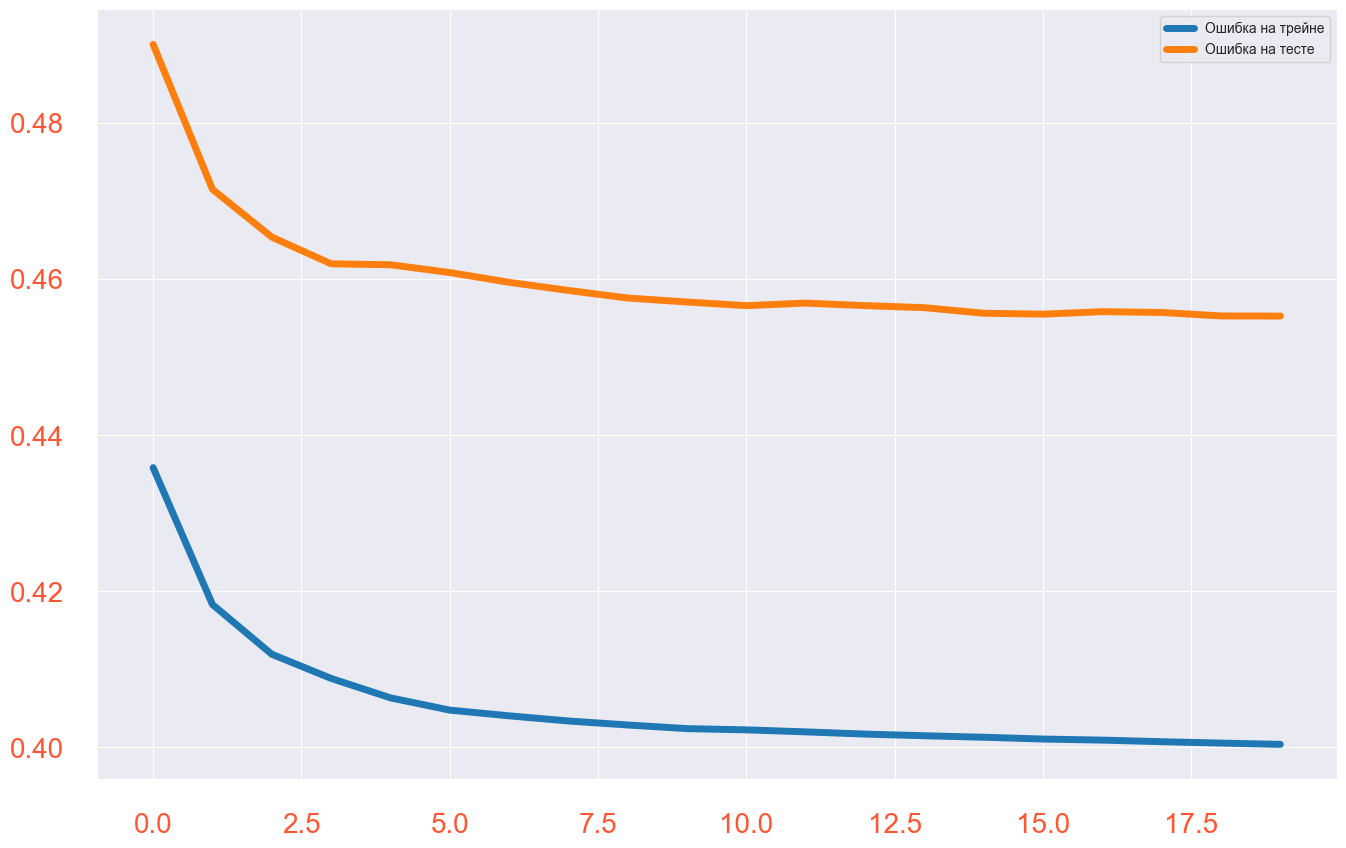

In [29]:
fig = plt.figure()
fig.set_size_inches(16, 10)

plt.plot(train_losses)
plt.plot(test_losses)

plt.legend(['Ошибка на трейне', 'Ошибка на тесте'])
plt.show()

### RandomForest

In [30]:
from sklearn.ensemble import RandomForestRegressor

randomForest_pipe = Pipeline([("column_transformer",
                               col_transform),
                              ("decision_tree",
                               RandomForestRegressor(max_depth=10,
                                                     verbose=1))])

randomForest_pipe.fit(X_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   21.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   44.3s finished


,steps,"[('column_transformer', ...), ('decision_tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('OneHotEncoder', ...), ('MeanTargetEncoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
train_preds = randomForest_pipe.predict(X_train)
test_preds = randomForest_pipe.predict(X_test)

train_error = np.mean((train_preds - y_train) ** 2)
test_error = np.mean((test_preds - y_test) ** 2)

print(f"Качество на трейне: {train_error.round(3)}")
print(f"Качество на тесте: {test_error.round(3)}")

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s


Качество на трейне: 0.401
Качество на тесте: 0.458


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [ ]:
from sklearn.model_selection import GridSearchCV

n_estimators = [int(x) for x in np.linspace(start=50, stop=400, num=3)]
max_depth = [int(x) for x in np.linspace(10, 51, num=4)]

param_grid = {'decision_tree__n_estimators': n_estimators,
              'decision_tree__max_depth': max_depth
              }

### Передадим в GridSearchCV

search = GridSearchCV(randomForest_pipe,
                      param_grid,
                      cv=splitter,
                      scoring='neg_mean_squared_error',
                      verbose=10)

search.fit(X_train, y_train)

print(f"Best parameter (CV score={search.best_score_:.5f}):")
print(search.best_params_)

print(f"Качество лучшей модели на финальном тесте: {search.score(X_test, y_test)}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3; 1/12] START decision_tree__max_depth=10, decision_tree__n_estimators=50


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.6s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    4.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished


[CV 1/3; 1/12] END decision_tree__max_depth=10, decision_tree__n_estimators=50;, score=-0.479 total time=   5.2s
[CV 2/3; 1/12] START decision_tree__max_depth=10, decision_tree__n_estimators=50


In [ ]:
### Грузим часть данных после 2017-01-01

df_train = pd.read_csv(
    'train.csv', usecols=[1, 2, 3, 4, 5],
    dtype={'onpromotion': bool},
    converters={'unit_sales': lambda u: np.log1p(
        float(u)) if float(u) > 0 else 0},
    parse_dates=["date"],
    skiprows=range(1, 66458909)  # 2016-01-01
)

df_train = df_train.loc[df_train.date >= pd.datetime(2017, 1, 1)]

### Для каждого (товар-магазин) на каждый день составим продажи

df_2017 = df_train.set_index(
    ["store_nbr", "item_nbr", "date"])[["unit_sales"]].unstack(
    level=-1).fillna(0)
df_2017.columns = df_2017.columns.get_level_values(1)